In [1]:
import pandas as pd

df = pd.read_csv("dataset_cleaned.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,super_genre,popularity_tier
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Acoustic,Hit
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Acoustic,Average
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Acoustic,Average
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Acoustic,Hit
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Acoustic,Hit


In [2]:
df.shape

(89740, 23)

In [3]:
summary = df["popularity"].describe()
print(summary)

count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


c:\Users\User\anaconda3\envs\uv_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


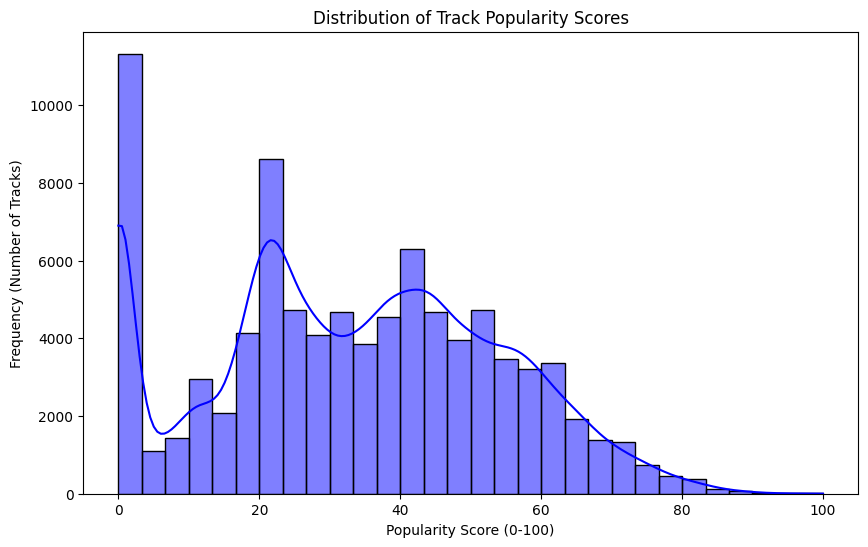

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


sns.histplot(df['popularity'], bins=30, kde=True, color='blue')


plt.title('Distribution of Track Popularity Scores')
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency (Number of Tracks)')


plt.show()

c:\Users\User\anaconda3\envs\uv_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


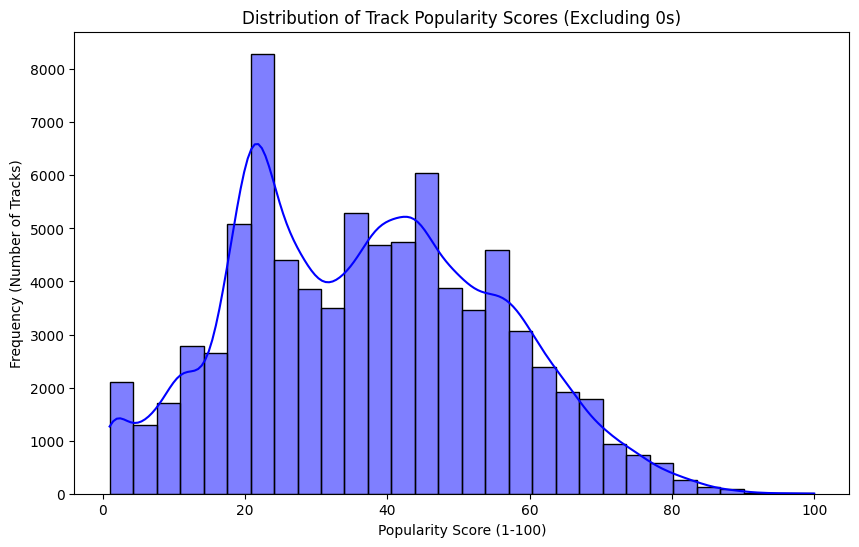

count    80293.000000
mean        37.104866
std         18.123541
min          1.000000
25%         22.000000
50%         37.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


df_clean = df[df['popularity'] > 0]


plt.figure(figsize=(10, 6))
sns.histplot(df_clean['popularity'], bins=30, kde=True, color='blue')

plt.title('Distribution of Track Popularity Scores (Excluding 0s)')
plt.xlabel('Popularity Score (1-100)')
plt.ylabel('Frequency (Number of Tracks)')
plt.show()


print(df_clean['popularity'].describe())

##### This distribution graph is the foundation of our analysis. It clearly shows that audience feedback (measured by popularity) is not uniform; it varies wildly from 1 to 100. Because we see this massive variance where most songs have average scores but a select few reach the high-popularity 'tail' on the right it justifies our core research question: What causes a song to reach that high-popularity tail? We hypothesize that the differentiating factor is how well the content aligns with audience preferences.

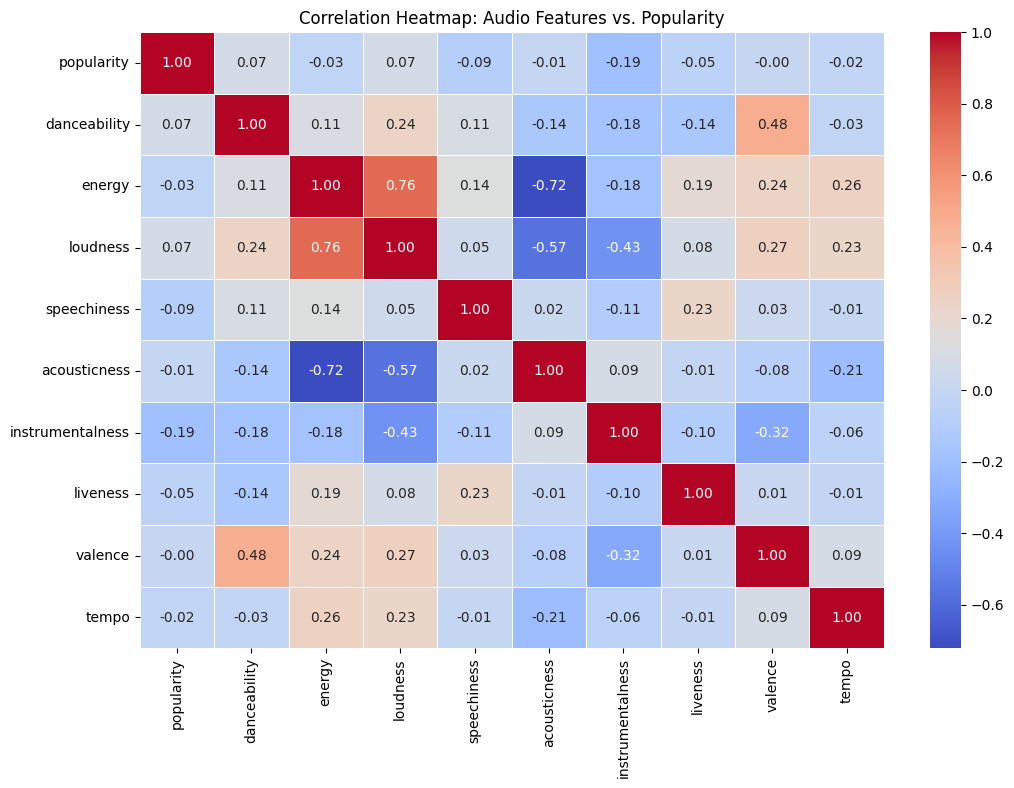

In [6]:
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 
                'speechiness', 'acousticness', 'instrumentalness', 
                'liveness', 'valence', 'tempo']

# Calculate the correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 8))

# annot=True puts the actual numbers in the squares
# cmap='coolwarm' makes positive correlations red and negative correlations blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Audio Features vs. Popularity')
plt.show()

Why are the correlations weak? Because you are looking at 114,000 tracks across 125 different genres mixed together.

What makes a Classical song popular (high acousticness, low energy) is the exact opposite of what makes a Heavy Metal song popular (high energy, high loudness).

When you mix them all together in one heatmap, they cancel each other out!

This provides the perfect transition to your Inferential Analytics phase. You can tell your evaluator: "The overall correlations were weak because 'Preference' depends on the 'Genre'. Therefore, I had to use ANOVA testing to break them down by category."

In [7]:
# Tier-wise descriptive profile for key audio features
features = ["danceability", "energy", "valence", "acousticness", "tempo", "loudness"]


In [ ]:
# Ensure order is Flop -> Average -> Hit
tier_profile = (
    df.groupby("popularity_tier")[features]
      .mean()
      .reindex(["Flop", "Average", "Hit"]) # Forces row order to Flop → Average → Hit (instead of random/alphabetical order)
      .round(3)
)

In [9]:

print("Average feature values by popularity tier:")
display(tier_profile)

Average feature values by popularity tier:


,danceability,energy,valence,acousticness,tempo,loudness
popularity_tier,,,,,,
Flop,0.548,0.638,0.474,0.335,121.975,-8.800
Average,0.572,0.627,0.460,0.331,122.253,-8.340
Hit,0.614,0.660,0.507,0.243,121.162,-6.897


In [ ]:
# Compare Hit vs Flop
comparison = pd.DataFrame({
    "Flop": tier_profile.loc["Flop"],
    "Hit": tier_profile.loc["Hit"]
})

## main descriptive question is, How do hits differ from flops?

In [ ]:
comparison["Difference(Hit-Flop)"] = (comparison["Hit"] - comparison["Flop"]).round(3)

# for each feature, subtracts Flop average from Hit average.
# Positive value means feature is higher in hits.
# Negative value means feature is lower in hits.

In [ ]:
def trend_label(x, tol=0.01):  # tol=0.01 is a small threshold
    if x > tol:
        return "Higher in Hit"
    elif x < -tol:
        return "Lower in Hit"
    return "Nearly same"

In [13]:
comparison["Trend"] = comparison["Difference(Hit-Flop)"].apply(trend_label)

print("\nHit vs Flop comparison:")
display(comparison.sort_values("Difference(Hit-Flop)", ascending=False))


Hit vs Flop comparison:


,Flop,Hit,Difference(Hit-Flop),Trend
loudness,-8.800,-6.897,1.903,Higher in Hit
danceability,0.548,0.614,0.066,Higher in Hit
valence,0.474,0.507,0.033,Higher in Hit
energy,0.638,0.660,0.022,Higher in Hit
acousticness,0.335,0.243,-0.092,Lower in Hit
tempo,121.975,121.162,-0.813,Lower in Hit


In [14]:
#Auto-generate interpretation lines
rise = comparison[comparison["Trend"] == "Higher in Hit"].index.tolist()
fall = comparison[comparison["Trend"] == "Lower in Hit"].index.tolist()
same = comparison[comparison["Trend"] == "Nearly same"].index.tolist()

line1 = f"Features that rise with popularity: {', '.join(rise) if rise else 'None'}."
line2 = f"Features that fall with popularity: {', '.join(fall) if fall else 'None'}."
line3 = (
    "This suggests audience-preferred sonic profile is "
    f"{'higher ' + ', '.join(rise) if rise else 'mixed'}, "
    "which supports the statement that aligned content gets better feedback."
)

print("\nInterpretation lines:")
print("1.", line1)
print("2.", line2)
print("3.", line3)


Interpretation lines:
1. Features that rise with popularity: danceability, energy, valence, loudness.
2. Features that fall with popularity: acousticness, tempo.
3. This suggests audience-preferred sonic profile is higher danceability, energy, valence, loudness, which supports the statement that aligned content gets better feedback.


#### We did this to describe how audio characteristics change across popularity levels (Flop, Average, Hit) before moving to inferential tests.

In short, this step helps to:

Identify which features are associated with higher feedback (popularity).
Build evidence for your statement that audience-aligned content performs better.